
### see original directory : 
##### /home/josh/Documents/Data_Analysis/SSOT/Codes_SSOT/machine_learning/QLattice-clinical-omics-main/notebooks

In [1]:
from platform import python_version
print(python_version())

3.10.12


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import feyn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from functions import *

feyn._qlattice._USE_V2_API=True

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.25.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


This version of feyn and the QLattice is available for academic, personal, and non-commercial use. By using the community version of this software you agree to the terms and conditions which can be found at `https://abzu.ai/eula`.


In [3]:
feyn.__version__

'3.0.5'

In [4]:
data_dir = '/media/josh/wd/data/IO_inhibitors/Kim2018_Gastric/Kim2018_PD1_Gastric_RNASeq'

In [5]:
hgnc = pd.read_csv('/media/josh/wd/data/ensembl_hgnc/hgnc_ncbi.txt', delimiter= '\t')


In [6]:
hgnc['NCBI Gene ID'] = hgnc['NCBI Gene ID'].astype('Int64')
hgnc['NCBI Gene ID'] = hgnc['NCBI Gene ID'].astype(str)

In [7]:
hgnc.head()

,HGNC ID,Approved symbol,Approved name,Status,Previous symbols,Alias symbols,Chromosome,Accession numbers,RefSeq IDs,NCBI Gene ID
0,HGNC:5,A1BG,alpha-1-B glycoprotein,Approved,NaN,NaN,19q13.43,NaN,NM_130786,1
1,HGNC:37133,A1BG-AS1,A1BG antisense RNA 1,Approved,"NCRNA00181, A1BGAS, A1BG-AS",FLJ23569,19q13.43,BC040926,NR_015380,503538
2,HGNC:24086,A1CF,APOBEC1 complementation factor,Approved,NaN,"ACF, ASP, ACF64, ACF65, APOBEC1CF",10q11.23,AF271790,NM_014576,29974
3,HGNC:6,A1S9T,"symbol withdrawn, see [HGNC:12469](/data/gene-...",Symbol Withdrawn,NaN,NaN,NaN,NaN,NaN,<NA>
4,HGNC:7,A2M,alpha-2-macroglobulin,Approved,NaN,"FWP007, S863-7, CPAMD5",12p13.31,"BX647329, X68728, M11313",NM_000014,2


In [8]:
protein_genes = pd.read_csv('/media/josh/wd/data/ensembl_hgnc/ensembl_ncbi_gene_ID.from_bioMart.csv')
protein_genes = protein_genes[protein_genes['gene_biotype'] == 'protein_coding']
protein_genes['entrezgene_id'] = protein_genes['entrezgene_id'].astype(('Int64'))
protein_genes['entrezgene_id'] = protein_genes['entrezgene_id'].astype(str)

protein_genes.head()

,ensembl_gene_id,hgnc_symbol,entrezgene_id,gene_biotype
0,ENSG00000011454,RABGAP1,23637,protein_coding
1,ENSG00000022277,RTF2,51507,protein_coding
2,ENSG00000028528,SNX1,6642,protein_coding
3,ENSG00000032742,IFT88,8100,protein_coding
4,ENSG00000035664,DAPK2,23604,protein_coding


In [9]:
gene_dict = dict(zip(hgnc['NCBI Gene ID'], hgnc['Approved symbol']))
gene_dict['1']

'A1BG'

In [10]:
X = pd.read_csv(f"{data_dir}/ICB.Kim2018_Pembrolizumab_Gastric.self_subtract", delimiter="\t")

In [11]:
X.index = X.Entrez
X = X.drop('Entrez', axis = 1)
X = X.T
X.columns = X.columns.astype(str)

X.head()

Entrez,1,29974,2,144568,3,127550,53947,51146,8086,65985,...,11130,7789,158586,79364,440590,100131879,79699,7791,23140,26009
PB-16-002,0.070753,-1.496310,-0.773153,-0.288607,-0.250342,0.082159,-0.047794,1.666055,-0.006938,0.033443,...,0.038622,0.013973,0.472940,0.017182,1.089776,-0.000745,0.324012,-0.700289,-0.941484,-0.293324
PB-16-003,-2.089767,-0.239171,0.521631,-0.459643,0.068639,-0.059665,-1.039765,1.774967,-0.473433,0.023231,...,-0.047835,0.344153,0.342393,-0.161278,0.233254,-0.000745,0.484621,-0.627792,0.910767,0.560360
PB-16-004,-1.435696,0.948275,0.912640,-0.384013,0.144291,0.049379,-0.591486,1.062668,-0.405411,-0.371900,...,0.016609,0.247330,0.328847,-0.029136,-0.107896,-0.000745,0.387544,-0.230124,0.918652,0.013647
PB-16-005,-0.760827,-1.240056,-0.308951,-0.449886,0.025890,-0.059665,-0.487542,0.674787,-0.305723,0.474107,...,0.756095,-0.218802,0.128380,0.351642,-0.028832,-0.000745,0.641866,-0.765318,0.147855,0.602364
PB-16-018,1.619985,1.921497,-2.752577,-0.317202,-0.393832,-0.006710,-0.609204,-2.278778,1.153734,1.845433,...,-0.291444,-0.120557,-0.409873,0.787259,0.468470,-0.000745,-0.333792,-1.407398,-0.765734,0.658216


In [12]:
X.iloc[1:3, 1:3]

Entrez,29974,2
PB-16-003,-0.239171,0.521631
PB-16-004,0.948275,0.912640


In [13]:
gene_list = [str(g) for g in X.columns]

common_prot_genes = list(set(gene_list).intersection(protein_genes['entrezgene_id'].to_list()))

In [14]:
protein_genes_sub = protein_genes[protein_genes['entrezgene_id'].isin(common_prot_genes)]

X = X[protein_genes_sub['entrezgene_id'].to_list()]
X.head()

Entrez,23637,51507,6642,8100,23604,3309,23626,4058,58524,5476,...,8447,57717,4700,386675,91689,55802,91689,147719,101060684,4700
PB-16-002,-0.943849,-0.060249,-0.534782,-0.513116,0.680565,-0.201702,-0.006595,-0.278689,-0.200166,0.508732,...,-0.972333,0.426784,-0.038169,-0.006225,0.494193,-0.579126,0.494193,-0.033523,-0.911148,-0.038169
PB-16-003,0.162798,-0.098466,-0.197470,0.019772,0.541486,-0.005631,-0.006595,1.167431,-0.200166,0.118398,...,-0.672742,0.319932,0.950808,-0.006225,-0.019444,0.267465,-0.019444,-0.033523,-0.630982,0.950808
PB-16-004,0.173503,-0.276308,0.035031,0.018206,0.561384,0.135269,-0.006595,1.135981,-0.200166,0.540652,...,-0.187780,0.011182,-1.590699,-0.006225,0.178518,0.182397,0.178518,0.072981,-0.984076,-1.590699
PB-16-005,-0.122700,0.244180,0.437299,0.161540,0.517079,-0.185022,-0.006595,0.911745,-0.200166,0.975871,...,-0.086060,-0.360244,1.356187,-0.006225,0.501024,0.208831,0.501024,0.073553,-0.472292,1.356187
PB-16-018,-0.533071,0.416760,-0.575395,-0.399652,1.483745,-0.400909,-0.006595,1.125442,-0.143997,-0.159660,...,-1.039153,-0.246648,1.566487,0.062929,0.002852,-0.333704,0.002852,-0.033523,-1.211031,1.566487


In [15]:
col_genes = [str(g) for g in X.columns]

common_genes = list(set(col_genes).intersection(hgnc['NCBI Gene ID'].to_list()))
common_genes = common_genes

In [16]:
hgnc_sub = hgnc[hgnc['NCBI Gene ID'].isin(common_genes)]


In [17]:
hgnc_sub.shape

(18346, 10)

In [18]:
select_genes = hgnc_sub['NCBI Gene ID'].to_list()
X_sub = X.loc[:, select_genes]

In [19]:
X_sub.head()

Entrez,1,29974,2,144568,127550,53947,51146,8086,65985,13,...,9183,55055,7789,158586,79364,440590,79699,7791,23140,26009
PB-16-002,0.070753,-1.496310,-0.773153,-0.288607,0.082159,-0.047794,1.666055,-0.006938,0.033443,0.702463,...,0.463121,-0.771567,0.013973,0.472940,0.017182,1.089776,0.324012,-0.700289,-0.941484,-0.293324
PB-16-003,-2.089767,-0.239171,0.521631,-0.459643,-0.059665,-1.039765,1.774967,-0.473433,0.023231,1.448811,...,0.208801,-0.456803,0.344153,0.342393,-0.161278,0.233254,0.484621,-0.627792,0.910767,0.560360
PB-16-004,-1.435696,0.948275,0.912640,-0.384013,0.049379,-0.591486,1.062668,-0.405411,-0.371900,1.382059,...,-0.104122,-0.227523,0.247330,0.328847,-0.029136,-0.107896,0.387544,-0.230124,0.918652,0.013647
PB-16-005,-0.760827,-1.240056,-0.308951,-0.449886,-0.059665,-0.487542,0.674787,-0.305723,0.474107,0.769009,...,0.122963,0.633897,-0.218802,0.128380,0.351642,-0.028832,0.641866,-0.765318,0.147855,0.602364
PB-16-018,1.619985,1.921497,-2.752577,-0.317202,-0.006710,-0.609204,-2.278778,1.153734,1.845433,-4.087904,...,-0.519456,1.558239,-0.120557,-0.409873,0.787259,0.468470,-0.333792,-1.407398,-0.765734,0.658216


In [20]:
X_sub.columns = [ gene_dict[c] for c in X_sub.columns]

In [21]:
X_sub.head()

,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AADAC,...,ZW10,ZWILCH,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
PB-16-002,0.070753,-1.496310,-0.773153,-0.288607,0.082159,-0.047794,1.666055,-0.006938,0.033443,0.702463,...,0.463121,-0.771567,0.013973,0.472940,0.017182,1.089776,0.324012,-0.700289,-0.941484,-0.293324
PB-16-003,-2.089767,-0.239171,0.521631,-0.459643,-0.059665,-1.039765,1.774967,-0.473433,0.023231,1.448811,...,0.208801,-0.456803,0.344153,0.342393,-0.161278,0.233254,0.484621,-0.627792,0.910767,0.560360
PB-16-004,-1.435696,0.948275,0.912640,-0.384013,0.049379,-0.591486,1.062668,-0.405411,-0.371900,1.382059,...,-0.104122,-0.227523,0.247330,0.328847,-0.029136,-0.107896,0.387544,-0.230124,0.918652,0.013647
PB-16-005,-0.760827,-1.240056,-0.308951,-0.449886,-0.059665,-0.487542,0.674787,-0.305723,0.474107,0.769009,...,0.122963,0.633897,-0.218802,0.128380,0.351642,-0.028832,0.641866,-0.765318,0.147855,0.602364
PB-16-018,1.619985,1.921497,-2.752577,-0.317202,-0.006710,-0.609204,-2.278778,1.153734,1.845433,-4.087904,...,-0.519456,1.558239,-0.120557,-0.409873,0.787259,0.468470,-0.333792,-1.407398,-0.765734,0.658216


In [22]:
Y = pd.read_csv(f"{data_dir}/ICB.Kim2018_Pembrolizumab_Gastric.clinical", delimiter="\t", index_col=0)
Y = Y[Y['Response'].notna()]
Y['Response'] = Y['Response'].astype('int')
Y['Response'].value_counts()

Response
0    42
1    15
Name: count, dtype: int64

In [23]:
data = pd.merge(Y, X_sub, left_index = True, right_index = True, how = 'inner')
data = data.loc[:,~data.columns.duplicated()].copy()
data.head()

,Response,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,...,ZW10,ZWILCH,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
PB-16-045,1,-1.194340,0.265465,-1.959851,-0.185928,0.300521,-0.602338,-2.137354,-0.060310,-0.020722,...,0.364883,1.061626,0.339017,0.025305,-0.073820,-0.224471,0.197393,-1.547198,-0.556127,0.511536
PB-16-068,1,-0.051136,0.414032,0.172315,1.307622,0.053857,1.908495,-2.268170,-0.300034,-1.458432,...,-0.113201,-0.244712,-0.313349,-0.273577,-0.219400,-0.198593,-0.223045,1.714241,-0.928192,-0.593405
PB-16-031,1,-1.099781,0.900167,-2.288308,-0.515128,-0.059665,-1.136929,-1.784351,0.164412,0.038618,...,0.150382,0.291803,-0.553154,-0.303159,0.356457,0.594387,0.119740,-0.772866,-0.591704,0.332500
PB-16-005,1,-0.760827,-1.240056,-0.308951,-0.449886,-0.059665,-0.487542,0.674787,-0.305723,0.474107,...,0.122963,0.633897,-0.218802,0.128380,0.351642,-0.028832,0.641866,-0.765318,0.147855,0.602364
PB-16-019,1,2.603073,0.786432,-0.968129,-0.132417,-0.059665,0.785180,-2.076505,-0.162548,0.266851,...,0.353638,0.086040,0.384324,0.230764,0.095406,-0.084323,-0.156881,-0.046176,0.496230,0.364295


In [24]:
# Define the semantic types
stypes = {}
for f in data.columns:
    if data[f].dtype =='object':
        stypes[f] = 'c'
        
# Set random seed for reproducibility
random_seed = 42

In [25]:
target = "Response"

## In depth modelling

### Get the test data

In [26]:
random_seed = 42
train_val, test = train_test_split(data, test_size=0.2, stratify=data[target], random_state=random_seed)

In [27]:
epochs = 50
criterion = 'bic'
max_complexity = 5
random_seed = 42
# sw = np.where(train_val[target] == 1, np.sum(train_val[target] == 0)/sum(train_val[target]), 1)
sw = np.where(data[target] == 1, np.sum(data[target] == 0)/sum(data[target]), 1)

In [28]:
# ql = feyn.connect_qlattice(server="https://qlattice.stage.abzu.ai") # Connecting
# ql = feyn.connect_qlattice()
# ql.reset(random_seed) # Resetting
ql = feyn.QLattice(random_seed=89)
# models_single = ql.auto_run(data = train_val,
#                          output_name = target,
#                          kind = "classification",
#                          stypes = stypes,
#                          n_epochs = epochs,
#                          criterion=criterion,
#                          max_complexity = max_complexity,
#                          sample_weights=sw)



models_single = ql.auto_run(data = data,
                         output_name = target,
                         kind = "classification",
                         stypes = stypes,
                         n_epochs = epochs,
                         criterion=criterion,
                         max_complexity = max_complexity,
                         sample_weights=sw)

## Model summary

In [29]:
# df_summary = modsum(models_single, train_val, test)[['N. Features', 'Functional form', 'BIC', 'Loss', 'AUC Train']]

df_summary = modsum(models_single, train_val, test)[['N. Features', 'Functional form', 'BIC', 'Loss', 'AUC Train']]


df_summary
# CALHM6
# CLPX
# CXCL11
# FAM26F
# GATB 
# PLEKHB1
# HENMT1

,N. Features,Functional form,BIC,Loss,AUC Train
0,2,logreg(DUSP4 + LAP3),5.29,0.016513,1.0
1,2,logreg(LAP3 + SH3TC1),6.43,0.029116,1.0
2,2,logreg(GRSF1 + LAP3),6.95,0.034939,0.99
3,3,logreg(GATB + KRT18 + LAP3),7.62,0.000021,1.0
4,3,logreg(ALKBH1 + FZD3 + TEKT1),7.62,0.000054,1.0
5,3,logreg(CYSRT1 + HEYL + LAP3),7.64,0.000336,1.0
6,3,logreg(FZD3 + PARD6A + SHISA2),7.7,0.001011,1.0
7,3,logreg(AHNAK + AIMP2 + FZD3),9.55,0.021496,1.0
8,2,logreg(COL6A2 + tanh(CXCL10)),9.69,0.023031,1.0
9,3,logreg(GCHFR + PAPLN + SLC34A2),10.36,0.030555,1.0


In [30]:
print(df_summary.to_latex())

\begin{tabular}{lrllrl}
\toprule
 & N. Features & Functional form & BIC & Loss & AUC Train \\
\midrule
0 & 2 & logreg(DUSP4 + LAP3) & 5.29 & 0.016513 & 1.0 \\
1 & 2 & logreg(LAP3 + SH3TC1) & 6.43 & 0.029116 & 1.0 \\
2 & 2 & logreg(GRSF1 + LAP3) & 6.95 & 0.034939 & 0.99 \\
3 & 3 & logreg(GATB + KRT18 + LAP3) & 7.62 & 0.000021 & 1.0 \\
4 & 3 & logreg(ALKBH1 + FZD3 + TEKT1) & 7.62 & 0.000054 & 1.0 \\
5 & 3 & logreg(CYSRT1 + HEYL + LAP3) & 7.64 & 0.000336 & 1.0 \\
6 & 3 & logreg(FZD3 + PARD6A + SHISA2) & 7.7 & 0.001011 & 1.0 \\
7 & 3 & logreg(AHNAK + AIMP2 + FZD3) & 9.55 & 0.021496 & 1.0 \\
8 & 2 & logreg(COL6A2 + tanh(CXCL10)) & 9.69 & 0.023031 & 1.0 \\
9 & 3 & logreg(GCHFR + PAPLN + SLC34A2) & 10.36 & 0.030555 & 1.0 \\
\bottomrule
\end{tabular}



## Best model from autorun (BIC criterion)

In [31]:
best_model = models_single[0]

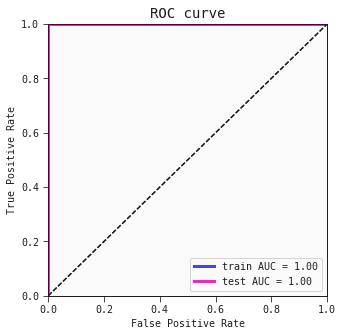

In [32]:
best_model.plot_roc_curve(train_val, label='train', figsize=(5,5))
best_model.plot_roc_curve(test, label='test', ax=plt.gca(), figsize=(5,5))
# plt.savefig(pathname+projectname+'roc_auc'+'.pdf', dpi=300, bbox_inches='tight')

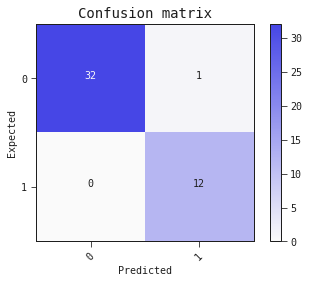

In [33]:
best_model.plot_confusion_matrix(data, filename='confusion_train'+'.pdf')
# best_model.plot_confusion_matrix(test, filename='confusion_ttest'+'.pdf')

# Plot feature conservation across models with dirac

In [34]:
(model_features_chart(data, models_single, metric="roc_auc_score"))

,roc_auc_score,LAP3,FZD3,TEKT1,SH3TC1,GRSF1,DUSP4,PAPLN,AIMP2,SHISA2,GCHFR,CYSRT1,KRT18,AHNAK,SLC34A2,PARD6A,COL6A2,ALKBH1,GATB,HEYL,CXCL10
Model#,,,,,,,,,,,,,,,,,,,,,
0,1.000000,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,1.000000,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,0.994949,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,1.000000,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False
4,1.000000,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
5,1.000000,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False
6,1.000000,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False
7,1.000000,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False
8,0.997475,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True


# Exploring model 0 further

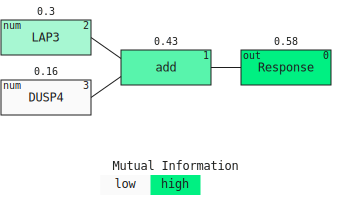

In [35]:
models_single[0].plot_signal(data,corr_func='mutual_information',
                             filename='bestmodel_signal_MI'+'.svg')

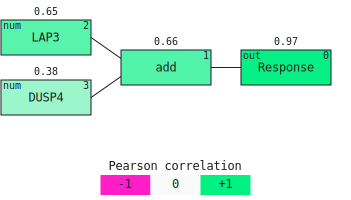

In [36]:
models_single[0].plot_signal(data, corr_func='pearson',filename='bestmodel_signal_PEARSON'+'.svg')

In [37]:
sympy_model = models_single[0].sympify(signif=3)
print(sympy_model.as_expr())

logreg(27.7*DUSP4 + 59.5*LAP3 - 37.7)


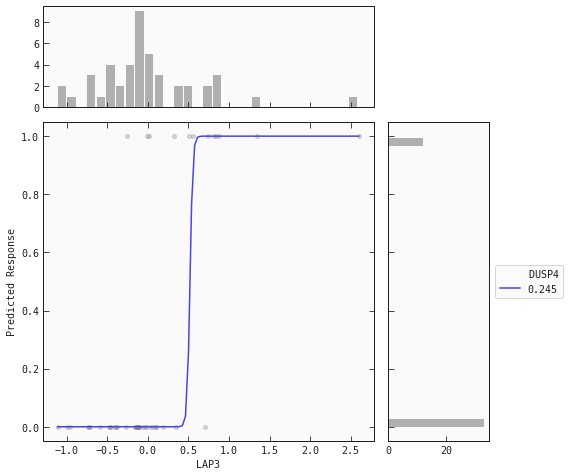

In [39]:
# show_quantiles = '_age at CSF collection'
# fixed = {}
# fixed[show_quantiles] = [
#     train_val[show_quantiles].quantile(q=0.25),
#     train_val[show_quantiles].quantile(q=0.5),
#     train_val[show_quantiles].quantile(q=0.75)
# ]

# best_model.plot_response_1d(data, by = 'MAPT', input_constraints=fixed, 
#                             filename=pathname+projectname+'bestmodel_response1d_age'+'.pdf')

best_model.plot_response_1d(data, by = 'LAP3', 
                            filename='bestmodel_response1d_RWDD4'+'.pdf')

In [43]:
# models_single[0].plot_response_2d(data, fixed={"IGLV4-69":15000})
# models_single[0].plot_response_2d(data, fixed={"LAP3":1})

ValueError: The amount of non-fixed inputs should be exactly two.

/home/josh/.local/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


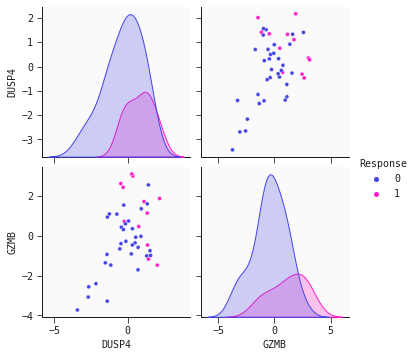

In [45]:
# DUSP4 + LAP3
# features_data = data[['DUSP4','LAP3',  'Response']]
features_data = data[['DUSP4','GZMB',  'Response']]
sns.pairplot(features_data, hue = target)

In [ ]:
# GZMB + HSBP1L1 + LTBP3

features_data = data[['GZMB','HSBP1L1', 'LTBP3', 'Response']]
sns.pairplot(features_data, hue = target)

# Cross-validation as a framework

In [ ]:
# results = crossvalidation_as_framework(data,
#                                      target,
#                                      kind = "classification",
#                                      stypes = stypes,
#                                      n_epochs = epochs,
#                                      criterion=criterion,
#                                      max_complexity = max_complexity)

In [ ]:
# # average performance of first 10 models
# results.roc_auc_val.mean(), results.accuracy_val.mean()

In [ ]:
# # average performance of first model
# results.groupby("fold").first().roc_auc_val.mean(), results.groupby("fold").first().accuracy_val.mean()

In [ ]:
# results.groupby("fold").first().roc_auc_val.std(), results.groupby("fold").first().accuracy_val.std()

In [ ]:
# results.groupby("fold").first()

In [ ]:
# results10 = crossvalidation_as_framework(data,
#                                      target,
#                                      kind = "classification",
#                                      stypes = stypes,
#                                      n_epochs = epochs,
#                                      criterion=criterion,
#                                      max_complexity = 10)

In [ ]:
# results10.groupby("fold").first().roc_auc_val.mean(), results10.groupby("fold").first().accuracy_val.mean()